## 1. Import data 

In [19]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [20]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
returns = pd.read_csv('data/returns.csv', index_col = 0, parse_dates = True)

print(len(t_eval))
returns


83


,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.031422,0.018084,0.032583,0.018862,-0.004644,-0.012545,-0.044299,-0.007982,0.014580,-0.063137,...,-0.002566,0.028546,-0.008275,0.048664,-0.074129,-0.032397,0.042081,0.014265,0.011796,-0.004679
2013-03-01,0.008662,0.099438,0.049106,-0.008801,0.008365,0.008993,0.048484,0.082105,0.069012,-0.060239,...,-0.034918,0.041559,0.005168,0.021489,0.084208,0.067982,0.043121,0.053017,0.055643,0.012602
2013-04-01,0.000271,0.121536,0.055981,0.087931,-0.048751,0.006270,-0.111507,0.010617,0.043753,-0.026802,...,-0.006162,0.027538,0.116043,0.020769,0.354112,0.050322,0.038232,0.026412,0.044325,-0.012507
2013-05-01,0.015574,-0.066551,-0.115501,-0.072696,0.058869,0.082198,0.165971,0.104060,0.046554,0.019661,...,-0.018989,-0.094067,-0.067541,-0.052416,0.593717,0.044067,0.044028,0.065476,-0.037760,0.016494
2013-06-01,-0.119298,-0.032134,-0.013318,-0.061870,0.031051,-0.030543,-0.009320,-0.060351,-0.083436,-0.039342,...,-0.018937,0.015880,-0.046110,0.011649,0.093672,0.044501,0.002182,0.025443,0.001292,0.005567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.030684,0.066755,0.021775,0.016470,-0.046413,0.062176,0.013231,0.010856,0.028467,0.032259,...,-0.093262,0.033902,0.086778,0.048106,-0.080549,0.024076,0.037234,-0.014770,0.117913,-0.005496
2024-09-01,0.018473,0.005942,0.031888,0.037234,0.042931,0.065546,0.057752,-0.026609,0.051542,0.093803,...,-0.047484,0.051096,0.009930,0.100323,0.200441,-0.009397,-0.032942,-0.026840,0.047416,0.001895
2024-10-01,-0.030902,0.031845,-0.038247,-0.085324,0.000376,0.042060,-0.012669,0.059026,0.038557,-0.038893,...,-0.039327,0.009381,0.013132,0.024249,-0.046071,-0.031585,-0.060242,0.139092,0.014751,-0.003761


## 2. PCA and Covariance Estimation

In [21]:
from sklearn.decomposition import PCA

lookback = 36
window = returns.iloc[-lookback-1:-1]
pca = PCA()
pca.fit(window)
variance_pct = pca.explained_variance_ratio_
cum_var = np.cumsum(variance_pct)
k = np.argmax(cum_var >= 0.8) + 1

Text(0.5, 1.0, 'Cross-Sectional Cumulative Variance')

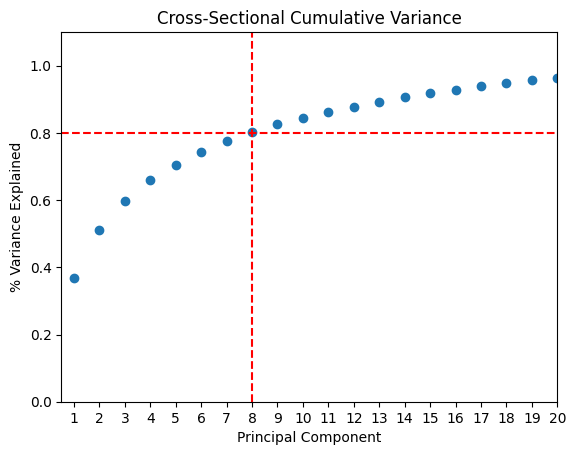

In [22]:

plt.scatter(range(1, 1 + len(cum_var)), cum_var)
plt.axhline(0.8, color = 'r', ls = '--')
plt.axvline(k, color = 'r', ls = '--')
plt.xlim(0.5,20)
plt.ylim(0,1.1)
plt.xticks(np.linspace(1,20,20))
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Cross-Sectional Cumulative Variance')



In [23]:
lookback = 36
threshold = 0.8
sigma_list = []

for t in range(lookback, len(returns)):
    # Lookback window
    window = returns.iloc[t-lookback:t]
    print(returns.index[t])
    # PCA deconstruction
    pca = PCA()
    pca.fit(window)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k = np.argmax(cum_var >= threshold)

    B = pca.components_[:k,:]
    F = np.diag(pca.explained_variance_[:k])

    sigma_pca = B.T @ F @ B

    sample_cov = window.cov().values

    D = np.diag(np.diag(sample_cov - sigma_pca))

    sigma_t = sigma_pca + D

    sigma_list.append(sigma_t)

# Stack along axis 2
sigma = np.stack(sigma_list, axis=2)
sigma


2016-02-01 00:00:00
2016-03-01 00:00:00
2016-04-01 00:00:00
2016-05-01 00:00:00
2016-06-01 00:00:00
2016-07-01 00:00:00
2016-08-01 00:00:00
2016-09-01 00:00:00
2016-10-01 00:00:00
2016-11-01 00:00:00
2016-12-01 00:00:00
2017-01-01 00:00:00
2017-02-01 00:00:00
2017-03-01 00:00:00
2017-04-01 00:00:00
2017-05-01 00:00:00
2017-06-01 00:00:00
2017-07-01 00:00:00
2017-08-01 00:00:00
2017-09-01 00:00:00
2017-10-01 00:00:00
2017-11-01 00:00:00
2017-12-01 00:00:00
2018-01-01 00:00:00
2018-02-01 00:00:00
2018-03-01 00:00:00
2018-04-01 00:00:00
2018-05-01 00:00:00
2018-06-01 00:00:00
2018-07-01 00:00:00
2018-08-01 00:00:00
2018-09-01 00:00:00
2018-10-01 00:00:00
2018-11-01 00:00:00
2018-12-01 00:00:00
2019-01-01 00:00:00
2019-02-01 00:00:00
2019-03-01 00:00:00
2019-04-01 00:00:00
2019-05-01 00:00:00
2019-06-01 00:00:00
2019-07-01 00:00:00
2019-08-01 00:00:00
2019-09-01 00:00:00
2019-10-01 00:00:00
2019-11-01 00:00:00
2019-12-01 00:00:00
2020-01-01 00:00:00
2020-02-01 00:00:00
2020-03-01 00:00:00


array([[[ 4.25223280e-03,  4.20656078e-03,  4.55059016e-03, ...,
          5.82968451e-03,  5.82990755e-03,  5.65383365e-03],
        [ 1.67071412e-03,  1.74005823e-03,  1.89541945e-03, ...,
          8.78938923e-04,  8.19946776e-04,  7.49536121e-04],
        [-1.55335802e-04, -6.21872354e-05,  1.60097023e-04, ...,
          1.65285747e-03,  1.67141633e-03,  1.63686257e-03],
        ...,
        [ 9.31893610e-04,  9.14874124e-04,  1.01253942e-03, ...,
          2.29471098e-03,  1.96959832e-03,  2.36777540e-03],
        [-2.41710026e-04, -1.65269855e-04, -7.23254768e-05, ...,
          1.89559626e-03,  1.82135183e-03,  2.00337053e-03],
        [ 1.19435266e-03,  1.15921969e-03,  1.33890336e-03, ...,
          7.31974597e-04,  5.84061294e-04,  6.39360878e-04]],

       [[ 1.67071412e-03,  1.74005823e-03,  1.89541945e-03, ...,
          8.78938923e-04,  8.19946776e-04,  7.49536121e-04],
        [ 4.59422301e-03,  4.59589734e-03,  4.41140168e-03, ...,
          4.30101392e-03,  4.25612316e

## 3. Risk-Adjusted Alpha Allocation

In [24]:
def standardise(df: pd.DataFrame) -> pd.DataFrame:
    def standardise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return df.apply(standardise_row, axis=1)

def normalise(df: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        tot = row.abs().sum()
        return row / tot

    return df.apply(normalise_row, axis=1)

In [25]:
scores = pd.read_csv('data/factor_scores.csv', index_col = 0, parse_dates = True)
scores_n = normalise(scores)
scores_n

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.010514,0.006478,0.098954,0.021092,0.018768,0.008923,0.019657,0.009981,0.015979,0.012601,...,-0.008098,0.001750,-0.000977,-0.018217,-0.020930,-0.005324,-0.006930,-0.003082,0.063782,0.014362
2018-02-01,-0.002795,0.002383,0.105227,0.012976,0.013086,0.005103,0.014080,0.003460,0.010283,0.012187,...,-0.003784,0.001258,0.012533,-0.018877,-0.028232,-0.001448,-0.006395,-0.001573,0.051300,0.012608
2018-03-01,-0.009019,0.011044,0.113633,0.004739,0.002323,0.007844,0.021134,-0.000002,0.007293,0.006775,...,0.000376,-0.002835,0.019025,-0.021101,-0.027000,-0.005754,-0.013317,-0.006892,0.030147,0.005441
2018-04-01,-0.000333,0.011635,0.105885,0.003640,0.001100,0.006009,0.018678,-0.001923,0.005540,0.005038,...,-0.007261,-0.002708,0.008556,-0.022868,-0.031713,-0.006831,-0.017717,-0.006479,0.040295,0.003020
2018-05-01,0.008055,0.006094,0.080756,0.010167,-0.001676,0.000936,0.015783,-0.005778,0.001617,0.001156,...,-0.004760,-0.002725,0.006323,-0.023883,-0.032322,-0.008631,-0.020268,-0.012322,0.043259,0.003271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.005054,0.000737,0.079117,0.040607,0.006281,-0.000683,-0.002150,0.000519,0.011142,-0.013755,...,0.009091,0.005146,-0.017517,-0.008462,-0.008196,-0.017845,-0.028991,0.027400,0.015242,0.006440
2024-08-01,0.000105,0.001431,0.077219,0.035277,0.022260,-0.011617,-0.011446,-0.009207,0.012069,-0.000502,...,0.026366,0.016691,-0.007051,-0.010091,0.010105,-0.020214,-0.019947,0.028764,0.016301,0.014456
2024-09-01,0.008415,0.011111,0.082626,0.041632,0.014910,0.004604,-0.008916,-0.001327,0.009329,-0.006267,...,0.017483,0.005880,-0.013677,-0.016325,0.001066,-0.017262,-0.022536,0.019604,0.012044,0.010154


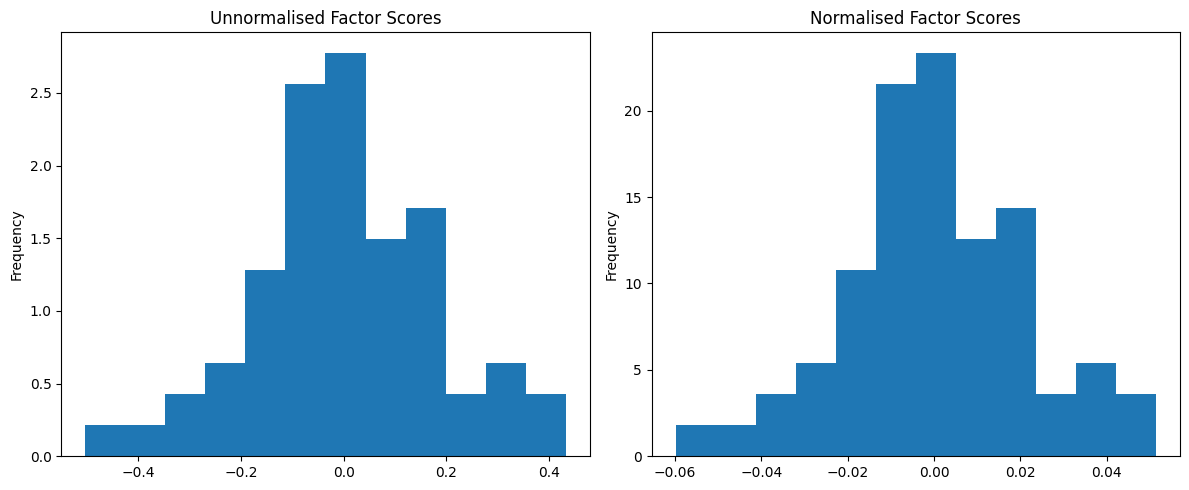

In [26]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))
scores.iloc[60].plot(ax = ax[0], kind = 'hist', bins = 12, density = True)
scores_n.iloc[60].plot(ax = ax[1], kind = 'hist', bins = 12, density = True)
ax[0].set_title('Unnormalised Factor Scores')
ax[1].set_title('Normalised Factor Scores')
plt.tight_layout()

In [27]:
t_eval = scores.index
sigma_t = sigma[:,:,-len(t_eval):]
sigma_t.shape

(60, 60, 83)

In [28]:
weights_t = pd.DataFrame(
    index = t_eval, 
    columns = scores.columns
)
for i,t in enumerate(t_eval):
    mu_t = scores_n.loc[t].values
    sigma_t_i = sigma[:,:,i]

    w = np.linalg.solve(sigma_t_i, mu_t)
    w = w - w.mean() # denorm
    w = w / np.abs(w).sum() # scale exposure

    weights_t.loc[t] = w

print(weights_t.sum(axis = 1))
print(weights_t.abs().sum(axis = 1))


Date
2018-01-01   -0.0
2018-02-01   -0.0
2018-03-01   -0.0
2018-04-01    0.0
2018-05-01   -0.0
             ... 
2024-07-01   -0.0
2024-08-01   -0.0
2024-09-01   -0.0
2024-10-01    0.0
2024-11-01   -0.0
Length: 83, dtype: object
Date
2018-01-01    1.0
2018-02-01    1.0
2018-03-01    1.0
2018-04-01    1.0
2018-05-01    1.0
             ... 
2024-07-01    1.0
2024-08-01    1.0
2024-09-01    1.0
2024-10-01    1.0
2024-11-01    1.0
Length: 83, dtype: object


In [ ]:
# Calculate Risk-adjusted Returns
returns_eval = pd.read_csv('data/returns_eval.csv', index_col = 0, parse_dates = True)

ra_returns = (returns_eval * weights_t).sum(axis = 1)
ra_returns.to_csv('outputs/ra_returns.csv')

## 4. Mean-Variance Optimisation

In [31]:
import cvxpy as cp

In [35]:
assets = scores.columns
n = len(assets)

weights_mvo = pd.DataFrame(index=t_eval, columns=assets)

lam = 1.0  # risk aversion parameter (tune this!)

for i, t in enumerate(t_eval):

    mu = scores_n.loc[t].values
    Sigma = sigma_t[:, :, i]

    w_mvo = cp.Variable(n)

    objective = cp.Maximize(
        mu @ w_mvo - 0.5 * lam * cp.quad_form(w_mvo, Sigma)
    )

    constraints = [
        cp.sum(w_mvo) == 0,          # market neutral
        cp.norm1(w_mvo) <= 1         # leverage constraint
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    weights_mvo.loc[t] = w_mvo.value

print(weights_mvo.abs().sum(axis = 1))
print(weights_mvo.sum(axis = 1))

Date
2018-01-01    1.0
2018-02-01    1.0
2018-03-01    1.0
2018-04-01    1.0
2018-05-01    1.0
             ... 
2024-07-01    1.0
2024-08-01    1.0
2024-09-01    1.0
2024-10-01    1.0
2024-11-01    1.0
Length: 83, dtype: object
Date
2018-01-01    0.0
2018-02-01    0.0
2018-03-01    0.0
2018-04-01    0.0
2018-05-01    0.0
             ... 
2024-07-01   -0.0
2024-08-01    0.0
2024-09-01    0.0
2024-10-01    0.0
2024-11-01    0.0
Length: 83, dtype: object
